# Calibrating the Lotka–Volterra Model

This notebook introduces model calibration using a simple predator–prey model.

We use a **simulation-based parameter recovery study**:

1. Generate synthetic observations using known parameter values.
2. Treat those parameter values as unknown.
3. Calibrate the model to recover them.
4. Compare the recovered parameters with the values used to generate the data.

Because the true parameter values are known, we can directly assess how well calibration works.

This provides a simple starting point before moving to calibration of a stochastic agent-based predator–prey model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from scipy.optimize import minimize
from caliagent.models import simulate_lotka_volterra

## Lotka–Volterra Predator–Prey Model

The Lotka–Volterra model describes interactions between a prey population and a predator population.

The model is **system-level**: rather than representing individual animals, it describes how the total predator and prey populations change through time.

The model contains four main parameters controlling prey growth, predation, predator mortality, and predator growth from predation.

## Simulation Study

We first generate synthetic observations using known parameter values.

| Parameter | Value |
| --- | ---: |
| Prey growth rate | 0.52 |
| Predation rate | 0.024 |
| Predator death rate | 0.84 |
| Predator growth from predation | 0.026 |
| Initial prey population | 34.0 |
| Initial predator population | 5.9 |

These values represent the **ground truth** that we will later attempt to recover through calibration.

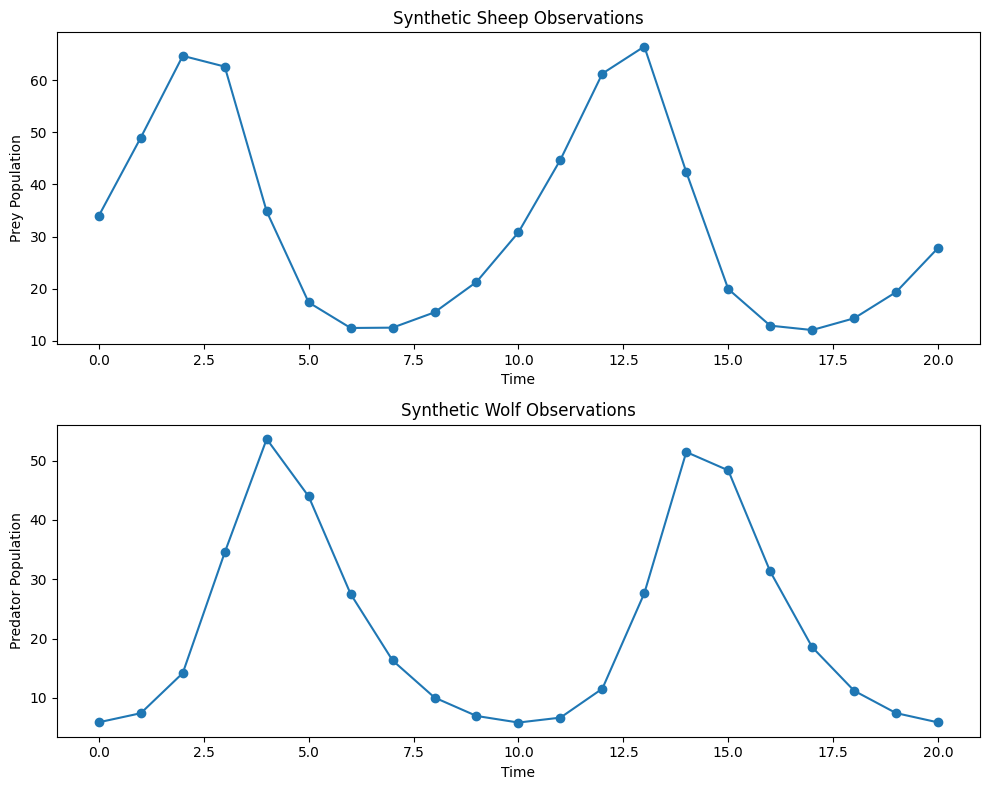

In [8]:
true_parameters = {
    "alpha": 0.52,
    "beta": 0.024,
    "gamma": 0.84,
    "delta": 0.026,
}

years = np.arange(0, 21)

observed = simulate_lotka_volterra(
    **true_parameters,
    h0=34.0,
    l0=5.9,
    years=years,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(
    observed["year"],
    observed["sheep"],
    marker="o",
)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Prey Population")
axes[0].set_title("Synthetic Sheep Observations")

axes[1].plot(
    observed["year"],
    observed["wolf"],
    marker="o",
)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Predator Population")
axes[1].set_title("Synthetic Wolf Observations")

plt.tight_layout()
plt.show()

## Starting Parameter Values

Suppose we do not know the parameters that generated the observations.

We begin with an initial guess and compare the resulting simulation with the observations.

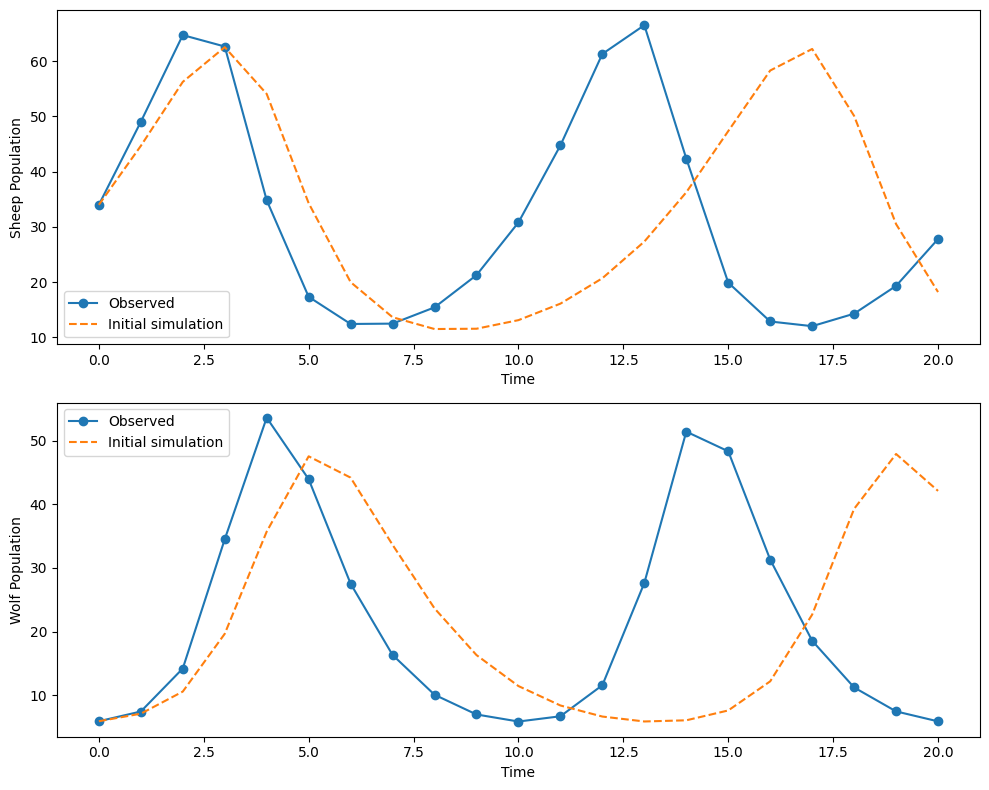

In [3]:
initial_parameters = {
    "alpha": 0.40,
    "beta": 0.020,
    "gamma": 0.60,
    "delta": 0.020,
}

initial_simulation = simulate_lotka_volterra(
    **initial_parameters,
    h0=observed["sheep"].iloc[0],
    l0=observed["wolf"].iloc[0],
    years=observed["year"].values,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(
    observed["year"],
    observed["sheep"],
    marker="o",
    label="Observed",
)
axes[0].plot(
    initial_simulation["year"],
    initial_simulation["sheep"],
    linestyle="--",
    label="Initial simulation",
)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Sheep Population")
axes[0].legend()

axes[1].plot(
    observed["year"],
    observed["wolf"],
    marker="o",
    label="Observed",
)
axes[1].plot(
    initial_simulation["year"],
    initial_simulation["wolf"],
    linestyle="--",
    label="Initial simulation",
)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Wolf Population")
axes[1].legend()

plt.tight_layout()
plt.show()

## Measuring Model Fit

Calibration requires a way to measure how closely the simulation matches the observations.

Here we use the **mean squared error** between the simulated and observed predator and prey trajectories.

Smaller error indicates a better fit.

In [4]:
def objective(params):
    """Return model error for a set of Lotka–Volterra parameters."""

    alpha, beta, gamma, delta = params

    simulated = simulate_lotka_volterra(
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        delta=delta,
        h0=observed["sheep"].iloc[0],
        l0=observed["wolf"].iloc[0],
        years=observed["year"].values,
    )

    sheep_error = np.mean(
        (
            simulated["sheep"].to_numpy()
            - observed["sheep"].to_numpy()
        ) ** 2
    )

    wolf_error = np.mean(
        (
            simulated["wolf"].to_numpy()
            - observed["wolf"].to_numpy()
        ) ** 2
    )

    return sheep_error + wolf_error

## Calibration by Optimisation

We now search for parameter values that minimise the difference between the simulated and observed trajectories.

Because the Lotka–Volterra model is smooth and deterministic, gradient-based optimisation is relatively straightforward.

In [10]:
x0 = np.array([
    0.40,
    0.020,
    0.60,
    0.020,
])

bounds = [
    (0.1, 2.0),
    (0.01, 0.14),
    (0.1, 2.0),
    (0.01, 0.1),
]

result = minimize(
    objective,
    x0=x0,
    method="L-BFGS-B",
    bounds=bounds,
)

parameter_recovery = pd.DataFrame({
    "Parameter": [
        "Prey growth rate",
        "Predation rate",
        "Predator death rate",
        "Predator growth from predation",
    ],
    "True": [
        0.52,
        0.024,
        0.84,
        0.026,
    ],
    "Recovered": result.x,
})

parameter_recovery["Percentage Difference"] = (
    100
    * (
        parameter_recovery["Recovered"]
        - parameter_recovery["True"]
    ).abs()
    / parameter_recovery["True"]
)

parameter_recovery

,Parameter,True,Recovered,Percentage Difference
0,Prey growth rate,0.520,0.520000,0.000046
1,Predation rate,0.024,0.024000,0.000075
2,Predator death rate,0.840,0.839999,0.000070
3,Predator growth from predation,0.026,0.026000,0.000079


## Simulate the calibrated model

We will run the Lotka-Volterra model again using calibrated parameters.

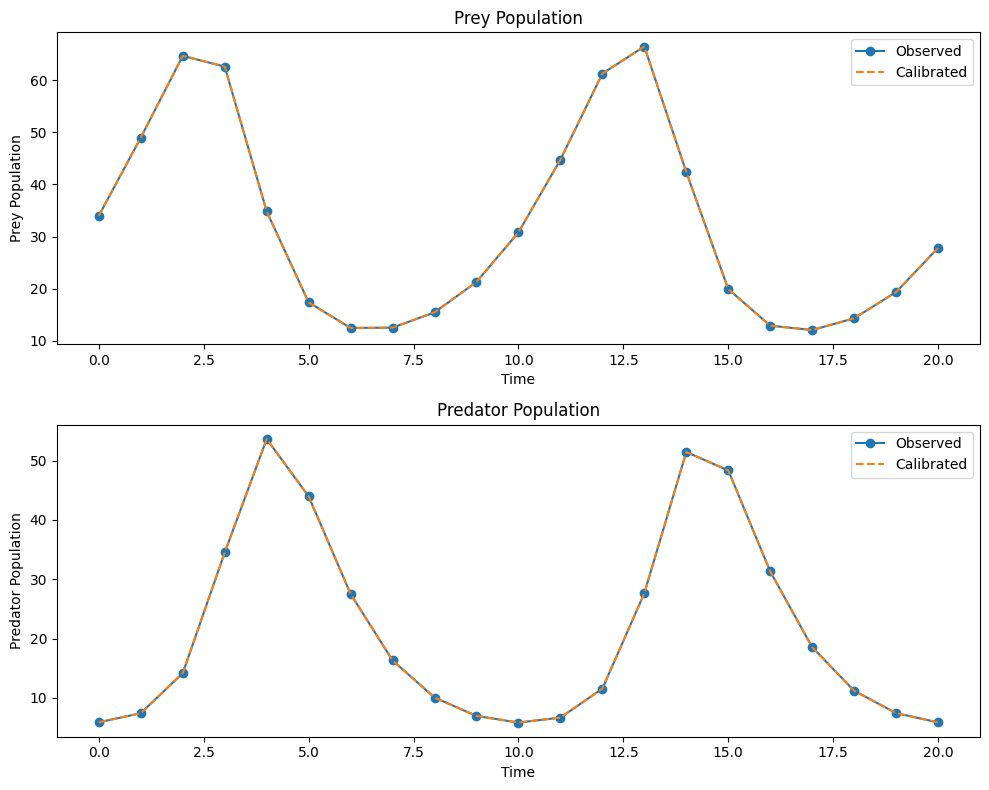

In [6]:
alpha, beta, gamma, delta = result.x

calibrated = simulate_lotka_volterra(
    alpha=alpha,
    beta=beta,
    gamma=gamma,
    delta=delta,
    h0=observed["sheep"].iloc[0],
    l0=observed["wolf"].iloc[0],
    years=observed["year"].values,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(
    observed["year"],
    observed["sheep"],
    marker="o",
    label="Observed",
)
axes[0].plot(
    calibrated["year"],
    calibrated["sheep"],
    linestyle="--",
    label="Calibrated",
)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Prey Population")
axes[0].set_title("Prey Population")
axes[0].legend()

axes[1].plot(
    observed["year"],
    observed["wolf"],
    marker="o",
    label="Observed",
)
axes[1].plot(
    calibrated["year"],
    calibrated["wolf"],
    linestyle="--",
    label="Calibrated",
)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Predator Population")
axes[1].set_title("Predator Population")
axes[1].legend()

plt.tight_layout()
plt.show()

## Did We Recover the Parameters?

Because the observations were generated from the same model used during calibration, we expect the optimiser to recover parameter values close to the ground truth.

This is known as **parameter recovery**.

A successful recovery demonstrates that, under these controlled conditions, the observations contain enough information for the calibration method to recover the parameters that generated them.

In real applications, the true parameter values are unknown and the model itself may only approximate the real system.

## What Changes for an Agent-Based Model?

The Lotka–Volterra example provides a relatively simple calibration problem:

- The model contains relatively few parameters.
- The population dynamics are explicitly defined.
- The model is deterministic.
- Simulations are computationally inexpensive.
- Model outputs are directly comparable with population-level observations.

The Wolf–Sheep agent-based model introduces additional challenges:

- Individual-level processes generate system-level behaviour.
- Simulations are stochastic.
- The same parameters can produce different outcomes.
- More simulations may be required to evaluate each parameter combination.
- Different parameter combinations may produce similar population-level behaviour.

These characteristics motivate the parameter-space exploration, replicate sampling, sensitivity analysis, optimisation, and Bayesian approaches considered next.

|  | **Lotka–Volterra** | **Wolf–Sheep ABM** |
| --- | --- | --- |
| Representation | System-level | Individual-level |
| Dynamics | Explicit | Often emergent |
| Stochasticity | Deterministic | Stochastic |
| Replicate runs | Usually unnecessary | Often important |
| Computational cost | Lower | Higher |
| Calibration | Relatively straightforward | Often more challenging |

In [7]:
import matplotlib.pyplot as plt

from ipywidgets import interact, FloatSlider


@interact(
    alpha=FloatSlider(
        value=0.52,
        min=0.1,
        max=3.0,
        step=0.01,
        description="Sheep reproduction",
    ),
    beta=FloatSlider(
        value=0.024,
        min=0.005,
        max=0.05,
        step=0.001,
        description="Predation",
    ),
    gamma=FloatSlider(
        value=0.84,
        min=0.1,
        max=3.0,
        step=0.01,
        description="Wolf mortality",
    ),
    delta=FloatSlider(
        value=0.026,
        min=0.005,
        max=0.05,
        step=0.001,
        description="Wolf growth",
    ),
)
def explore_model(alpha, beta, gamma, delta):
    simulated = simulate_lotka_volterra(
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        delta=delta,
        h0=observed["sheep"].iloc[0],
        l0=observed["wolf"].iloc[0],
        years=observed["year"].values,
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    # Observed
    ax.plot(
        observed["year"],
        observed["sheep"],
        marker="o",
        linestyle="",
        label="Observed sheep",
    )

    ax.plot(
        observed["year"],
        observed["wolf"],
        marker="o",
        linestyle="",
        label="Observed wolves",
    )

    # Simulated
    ax.plot(
        simulated["year"],
        simulated["sheep"],
        linestyle="--",
        label="Simulated sheep",
    )

    ax.plot(
        simulated["year"],
        simulated["wolf"],
        linestyle="--",
        label="Simulated wolves",
    )

    ax.set_xlabel("Year")
    ax.set_ylabel("Population")
    ax.set_title("Explore Lotka–Volterra Parameters")
    ax.legend()

    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=0.52, description='Sheep reproduction', max=3.0, min=0.1, step=0.01), …